In [89]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [90]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [91]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [92]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  sum_jumps = sum(jumps)
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  cols.append(len(list(set(jumps))))
  cols.append(int(any([b == sum_jumps for b in bolillas_int])))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff", "hjsum"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String,
    "jdiff": pl.String,
    "jsum": pl.String,
    "hjsum": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2544


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""07/01/2026""","""1262""","""05 34 26 02 09 47""","""40""","""35 27 49""","""Promoción Sí o Sí""","""020509263447""","[2, 5, … 47]",2,5,9,26,34,47,"""02""","""05""","""09""","""26""","""34""","""47""",null,null,null,null,null,null,true,16,"""03_04_17_08_13""",70,"""3""","""3""","""3""","""3""","""4""","""17""","""8""","""13""","""45""","""2""","""5""","""0"""
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""28/12/2025""","""1259""","""06 13 31 22 11 16""","""19""","""15 10""","""Promoción Sí o Sí""","""061113162231""","[6, 11, … 31]",6,11,13,16,22,31,"""06""","""11""","""13""","""16""","""22""","""31""","""28""","""35""","""37""","""38""","""44""","""47""",false,0,"""05_02_03_06_09""",0,"""3""","""3""","""3""","""5""","""2""","""3""","""6""","""9""","""25""","""0""","""5""","""0"""
"""24/12/2025""","""1258""","""16 13 31 08 24 33""","""01""","""45 11 22""","""Promoción Sí o Sí""","""081316243133""","[8, 13, … 33]",8,13,16,24,31,33,"""08""","""13""","""16""","""24""","""31""","""33""","""06""","""11""","""13""","""16""","""22""","""31""",false,0,"""05_03_08_07_02""",15,"""2""","""3""","""3""","""5""","""3""","""8""","""7""","""2""","""25""","""0""","""5""","""0"""
"""21/12/2025""","""1257""","""25 27 23 36 14 10""","""38""","""03""","""Promoción Sí o Sí""","""101423252736""","[10, 14, … 36]",10,14,23,25,27,36,"""10""","""14""","""23""","""25""","""27""","""36""","""08""","""13""","""16""","""24""","""31""","""33""",true,8,"""04_09_02_02_09""",-19,"""1""","""3""","""3""","""4""","""9""","""2""","""2""","""9""","""26""","""0""","""3""","""0"""
"""17/12/2025""","""1256""","""14 25 10 13 12 39""","""49""","""37 09 29""","""Promoción Sí o Sí""","""101213142539""","[10, 12, … 39]",10,12,13,14,25,39,"""10""","""12""","""13""","""14""","""25""","""39""","""10""","""14""","""23""","""25""","""27""","""36""",true,8,"""02_01_01_11_14""",-26,"""1""","""3""","""3""","""2""","""1""","""1""","""11""","""14""","""29""","""2""","""4""","""0"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""10/12/2025""","""1254""","""36 21 07 38 47 48""","""03""","""23 01 50""","""Promoción Sí o Sí""","""072136384748""","[7, 21, … 48]",7,21,36,38,47,48,"""07""","""21""","""36""","""38""","""47""","""48""","""14""","""19""","""27""","""35""","""37""","""50""",false,0,"""14_15_02_09_01""",-69,"""2""","""3""","""3""","""14""","""15""","""2""","""9""","""1""","""41""","""2""","""5""","""0"""


In [93]:
dfRows.filter(
  pl.col("b1") > 10
)

fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""04/01/2026""","""1261""","""23 49 26 48 39 21""","""01""","""30""","""Promoción Sí o Sí""","""212326394849""","[21, 23, … 49]",21,23,26,39,48,49,"""21""","""23""","""26""","""39""","""48""","""49""","""02""","""05""","""09""","""26""","""34""","""47""",false,0,"""02_03_13_09_01""",33,"""1""","""2""","""4""","""2""","""3""","""13""","""9""","""1""","""28""","""1""","""5""","""0"""
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""14/12/2025""","""1255""","""19 37 50 27 35 14""","""39""","""08""","""Promoción Sí o Sí""","""141927353750""","[14, 19, … 50]",14,19,27,35,37,50,"""14""","""19""","""27""","""35""","""37""","""50""","""10""","""12""","""13""","""14""","""25""","""39""",true,8,"""05_08_08_02_13""",26,"""2""","""2""","""4""","""5""","""8""","""8""","""2""","""13""","""36""","""1""","""4""","""0"""
"""07/12/2025""","""1253""","""45 46 32 28 11 43""","""35""","""10 02""","""Promoción Sí o Sí""","""112832434546""","[11, 28, … 46]",11,28,32,43,45,46,"""11""","""28""","""32""","""43""","""45""","""46""","""07""","""21""","""36""","""38""","""47""","""48""",false,0,"""17_04_11_02_01""",60,"""2""","""3""","""3""","""17""","""4""","""11""","""2""","""1""","""35""","""2""","""5""","""0"""
"""03/12/2025""","""1252""","""29 25 28 43 12 33""","""27""","""31 26 34 37""","""Promoción Sí o Sí""","""122528293343""","[12, 25, … 43]",12,25,28,29,33,43,"""12""","""25""","""28""","""29""","""33""","""43""","""11""","""28""","""32""","""43""","""45""","""46""",false,0,"""13_03_01_04_10""",1,"""2""","""2""","""4""","""13""","""3""","""1""","""4""","""10""","""31""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10/09/1995""","""0048""","""11 19 20 21 24 36""","""""","""""","""""","""111920212436""","[11, 19, … 36]",11,19,20,21,24,36,"""11""","""19""","""20""","""21""","""24""","""36""","""10""","""13""","""17""","""21""","""23""","""32""",true,8,"""08_01_01_03_12""",10,"""2""","""3""","""3""","""8""","""1""","""1""","""3""","""12""","""25""","""1""","""4""","""0"""
"""23/07/1995""","""0041""","""14 18 21 25 29 30""","""""","""""","""""","""141821252930""","[14, 18, … 30]",14,18,21,25,29,30,"""14""","""18""","""21""","""25""","""29""","""30""","""03""","""04""","""06""","""10""","""16""","""29""",true,8,"""04_03_04_04_01""",1,"""1""","""3""","""3""","""4""","""3""","""4""","""4""","""1""","""16""","""0""","""3""","""0"""
"""09/04/1995""","""0026""","""16 18 24 25 29 31""","""""","""""","""""","""161824252931""","[16, 18, … 31]",16,18,24,25,29,31,"""16""","""18""","""24""","""25""","""29""","""31""","""01""","""03""","""19""","""27""","""30""","""35""",false,0,"""02_06_01_04_02""",-30,"""2""","""3""","""3""","""2""","""6""","""1""","""4""","""2""","""15""","""0""","""4""","""0"""


In [94]:

def count_column (df: pl.DataFrame, col_name: str, k: int = None) -> None:
  df_viz = (df if k == None else df[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

jjsum = count_column(dfRows, 'hjsum', 200)
jdiff_count = count_column(dfRows, 'jdiff', 200)

j1_count = count_column(dfRows, 'j1', 200)
j2_count = count_column(dfRows, 'j2', 200)
j3_count = count_column(dfRows, 'j3', 200)
j4_count = count_column(dfRows, 'j4', 200)
j5_count = count_column(dfRows, 'j5', 200)

joor_count = count_column(dfRows, "joor", 200)
primes_count = count_column(dfRows, 'primes_count', 200)
evens_count = count_column(dfRows, 'evens_count', 200)
odds_count = count_column(dfRows, 'odds_count', 200)

jsums = count_column(dfRows, 'jsum', 200)
# print(jsums[0:22])



:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [95]:
dfRows.item(0, 'b2')

5

In [96]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [97]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='02'
df_viz FOR str_b1 = 02


post_str_b1,count,percent
str,u32,f64
"""01""",43,13.782051
"""02""",35,11.217949
"""04""",29,9.294872
"""05""",28,8.974359
"""03""",25,8.012821
…,…,…
"""21""",2,0.641026
"""18""",1,0.320513
"""29""",1,0.320513


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 02
Last 3 results last_results=['04', '03', '08']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""19/11/2025""","""1248""","""28 40 02 44 21 33""","""15""","""25""","""Promoción Sí o Sí""","""022128334044""","[2, 21, … 44]",2,21,28,33,40,44,"""02""","""21""","""28""","""33""","""40""","""44""","""03""","""07""","""10""","""12""","""45""","""49""",false,0,"""19_07_05_07_04""",-3,"""1""","""4""","""2""","""19""","""7""","""5""","""7""","""4""","""42""","""1""","""4""","""0"""
"""12/11/2025""","""1246""","""31 06 22 02 04 17""","""44""","""39 36""","""Promoción Sí o Sí""","""020406172231""","[2, 4, … 31]",2,4,6,17,22,31,"""02""","""04""","""06""","""17""","""22""","""31""","""04""","""10""","""15""","""41""","""44""","""46""",true,8,"""02_02_11_05_09""",49,"""3""","""4""","""2""","""2""","""2""","""11""","""5""","""9""","""29""","""1""","""4""","""0"""
"""26/10/2025""","""1241""","""46 02 17 32 12 15""","""40""","""48 10 43""","""Promoción Sí o Sí""","""021215173246""","[2, 12, … 46]",2,12,15,17,32,46,"""02""","""12""","""15""","""17""","""32""","""46""","""08""","""13""","""14""","""27""","""33""","""44""",false,0,"""10_03_02_15_14""",-36,"""2""","""4""","""2""","""10""","""3""","""2""","""15""","""14""","""44""","""3""","""5""","""0"""
"""05/10/2025""","""1235""","""02 31 06 14 45 23""","""05""","""""","""""","""020614233145""","[2, 6, … 45]",2,6,14,23,31,45,"""02""","""06""","""14""","""23""","""31""","""45""","""08""","""23""","""25""","""29""","""39""","""40""",false,0,"""04_08_09_08_14""",8,"""3""","""3""","""3""","""4""","""8""","""9""","""8""","""14""","""43""","""1""","""4""","""0"""
"""21/09/2025""","""1231""","""46 44 02 28 20 32""","""39""","""""","""""","""022028324446""","[2, 20, … 46]",2,20,28,32,44,46,"""02""","""20""","""28""","""32""","""44""","""46""","""21""","""24""","""31""","""39""","""43""","""46""",true,20,"""18_08_04_12_02""",-36,"""1""","""6""","""0""","""18""","""8""","""4""","""12""","""2""","""44""","""2""","""5""","""1"""
"""14/09/2025""","""1229""","""35 06 12 33 38 02""","""14""","""44 46""","""Promoción Sí o Sí""","""020612333538""","[2, 6, … 38]",2,6,12,33,35,38,"""02""","""06""","""12""","""33""","""35""","""38""","""14""","""19""","""24""","""34""","""39""","""44""",false,0,"""04_06_21_02_03""",101,"""1""","""4""","""2""","""4""","""6""","""21""","""2""","""3""","""36""","""1""","""5""","""0"""
"""03/08/2025""","""1217""","""45 41 02 14 23 46""","""22""","""05 39""","""Promoción Sí o Sí""","""021423414546""","[2, 14, … 46]",2,14,23,41,45,46,"""02""","""14""","""23""","""41""","""45""","""46""","""06""","""21""","""23""","""33""","""36""","""38""",false,0,"""12_09_18_04_01""",69,"""3""","""3""","""3""","""12""","""9""","""18""","""4""","""1""","""44""","""2""","""5""","""0"""
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2""","""5""","""0"""
"""01/06/2025""","""1199""","""02 16 19 14 43 22""","""04""","""17 48 27""","""Promoción Sí o Sí""","""021416192243""","[2, 14, … 43]",2,14,16,19,22,43,"""02""","""14""","""16""","""19""","""22""","""43""","""01""","""05""","""21""","""30""","""36""","""50""",true,8,"""12_02_03_03_21""",31,"""3""","""4""","""2""","""12""","""2""","""3""","""3""","""21""","""41""","""2""","""4""","""0"""


df_jumps_map FOR str_b1 = 02


jumps_map,count
str,u32
"""01_08_11_03_15""",1
"""06_10_02_01_14""",1
"""10_04_02_03_16""",1
"""13_03_07_05_02""",1
"""04_04_02_02_25""",1
…,…
"""04_07_11_05_04""",1
"""02_18_05_05_07""",1
"""07_12_05_10_09""",1


df_unijump FOR str_b1 = 02


unijump,count
i64,u32
3,9
-11,6
-35,5
29,5
15,5
…,…
-87,1
11,1
159,1


In [98]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='05'
df_viz FOR str_b2 = 05


post_str_b2,count,percent
str,u32,f64
"""18""",10,8.849558
"""11""",9,7.964602
"""09""",9,7.964602
"""10""",6,5.309735
"""05""",6,5.309735
…,…,…
"""33""",1,0.884956
"""29""",1,0.884956
"""28""",1,0.884956


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 05
Last 3 results last_results=['06', '28', '08']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""19/10/2025""","""1239""","""15 32 03 23 05 47""","""46""","""27 08 02 12""","""Promoción Sí o Sí""","""030515233247""","[3, 5, … 47]",3,5,15,23,32,47,"""03""","""05""","""15""","""23""","""32""","""47""","""04""","""06""","""07""","""11""","""18""","""45""",true,1,"""02_10_08_09_15""",-11,"""4""","""1""","""5""","""2""","""10""","""8""","""9""","""15""","""44""","""2""","""5""","""0"""
"""04/06/2025""","""1200""","""01 36 50 30 05 21""","""37""","""09 24 43""","""Promoción Sí o Sí""","""010521303650""","[1, 5, … 50]",1,5,21,30,36,50,"""01""","""05""","""21""","""30""","""36""","""50""","""05""","""08""","""12""","""18""","""25""","""34""",false,0,"""04_16_09_06_14""",-16,"""1""","""3""","""3""","""4""","""16""","""9""","""6""","""14""","""49""","""2""","""5""","""0"""
"""26/03/2025""","""1180""","""43 01 05 37 35 13""","""39""","""38 07 45 16""","""Promoción Sí o Sí""","""010513353743""","[1, 5, … 43]",1,5,13,35,37,43,"""01""","""05""","""13""","""35""","""37""","""43""","""25""","""28""","""29""","""31""","""46""","""47""",true,19,"""04_08_22_02_06""",102,"""4""","""0""","""6""","""4""","""8""","""22""","""2""","""6""","""42""","""1""","""5""","""0"""
"""25/12/2024""","""1154""","""14 39 24 02 05 15""","""44""","""48 27 34 38""","""Promoción Sí o Sí""","""020514152439""","[2, 5, … 39]",2,5,14,15,24,39,"""02""","""05""","""14""","""15""","""24""","""39""","""29""","""35""","""41""","""42""","""49""","""50""",false,0,"""03_09_01_09_15""",-48,"""2""","""3""","""3""","""3""","""9""","""1""","""9""","""15""","""37""","""1""","""4""","""0"""
"""14/07/2024""","""1107""","""43 03 34 05 42 26""","""29""","""08 33""","""Promoción Sí o Sí""","""030526344243""","[3, 5, … 43]",3,5,26,34,42,43,"""03""","""05""","""26""","""34""","""42""","""43""","""01""","""19""","""38""","""40""","""43""","""47""",true,24,"""02_21_08_08_01""",-65,"""3""","""3""","""3""","""2""","""21""","""8""","""8""","""1""","""40""","""1""","""4""","""0"""
"""24/04/2024""","""1084""","""43 05 24 37 26 04""","""46""","""23 15""","""Promoción Sí o Sí""","""040524263743""","[4, 5, … 43]",4,5,24,26,37,43,"""04""","""05""","""24""","""26""","""37""","""43""","""06""","""22""","""25""","""36""","""41""","""43""",true,16,"""01_19_02_11_06""",-101,"""3""","""3""","""3""","""1""","""19""","""2""","""11""","""6""","""39""","""2""","""5""","""0"""
"""05/07/2023""","""1000""","""34 28 11 01 24 05""","""30""","""42 39 44 09 32""","""Promoción Sí o Sí""","""010511242834""","[1, 5, … 34]",1,5,11,24,28,34,"""01""","""05""","""11""","""24""","""28""","""34""","""06""","""11""","""21""","""26""","""29""","""38""",false,0,"""04_06_13_04_06""",48,"""2""","""3""","""3""","""4""","""6""","""13""","""4""","""6""","""33""","""1""","""3""","""0"""
"""28/05/2023""","""0989""","""01 05 21 38 10 36""","""31""","""28 39 27""","""Promoción Sí o Sí""","""010510213638""","[1, 5, … 38]",1,5,10,21,36,38,"""01""","""05""","""10""","""21""","""36""","""38""","""09""","""11""","""16""","""40""","""41""","""43""",false,0,"""04_05_11_15_02""",-8,"""1""","""3""","""3""","""4""","""5""","""11""","""15""","""2""","""37""","""2""","""5""","""0"""
"""26/02/2023""","""0963""","""16 02 46 43 28 05""","""38""","""22 21""","""Promoción Sí o Sí""","""020516284346""","[2, 5, … 46]",2,5,16,28,43,46,"""02""","""05""","""16""","""28""","""43""","""46""","""07""","""14""","""27""","""31""","""33""","""38""",false,0,"""03_11_12_15_03""",-26,"""3""","""4""","""2""","""3""","""11""","""12""","""15""","""3""","""44""","""3""","""4""","""0"""


df_jumps_map FOR str_b2 = 05


jumps_map,count
str,u32
"""03_07_14_01_03""",1
"""04_02_04_15_15""",1
"""03_07_09_02_15""",1
"""04_25_06_02_01""",1
"""02_07_05_01_19""",1
…,…
"""02_04_06_09_01""",1
"""04_08_22_02_06""",1
"""04_01_06_12_16""",1


df_unijump FOR str_b2 = 05


unijump,count
i64,u32
-24,5
-37,3
-7,2
-15,2
-48,2
…,…
-14,1
-78,1
36,1


In [99]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='09'
df_viz FOR str_b3 = 09


post_str_b3,count,percent
str,u32,f64
"""16""",5,11.111111
"""25""",5,11.111111
"""14""",4,8.888889
"""13""",4,8.888889
"""21""",3,6.666667
…,…,…
"""05""",1,2.222222
"""27""",1,2.222222
"""12""",1,2.222222


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 09
Last 3 results last_results=['16', '13', '23']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""30/07/2025""","""1216""","""43 28 03 09 01 25""","""23""","""31""","""Promoción Sí o Sí""","""010309252843""","[1, 3, … 43]",1,3,9,25,28,43,"""01""","""03""","""09""","""25""","""28""","""43""","""02""","""14""","""23""","""41""","""45""","""46""",false,0,"""02_06_16_03_15""",77,"""2""","""1""","""5""","""2""","""6""","""16""","""3""","""15""","""42""","""2""","""5""","""0"""
"""28/05/2025""","""1198""","""02 16 15 50 09 04""","""37""","""30 25 49 13""","""Promoción Sí o Sí""","""020409151650""","[2, 4, … 50]",2,4,9,15,16,50,"""02""","""04""","""09""","""15""","""16""","""50""","""02""","""14""","""16""","""19""","""22""","""43""",true,16,"""02_05_06_01_34""",48,"""1""","""4""","""2""","""2""","""5""","""6""","""1""","""34""","""48""","""1""","""5""","""0"""
"""14/05/2025""","""1194""","""38 07 12 13 04 09""","""42""","""46 28""","""Promoción Sí o Sí""","""040709121338""","[4, 7, … 38]",4,7,9,12,13,38,"""04""","""07""","""09""","""12""","""13""","""38""","""09""","""11""","""13""","""15""","""33""","""42""",false,0,"""03_02_03_01_25""",34,"""2""","""3""","""3""","""3""","""2""","""3""","""1""","""25""","""34""","""1""","""4""","""0"""
"""26/06/2024""","""1102""","""43 06 14 01 09 11""","""30""","""17 42 45 20""","""Promoción Sí o Sí""","""010609111443""","[1, 6, … 43]",1,6,9,11,14,43,"""01""","""06""","""09""","""11""","""14""","""43""","""13""","""15""","""34""","""38""","""42""","""48""",true,16,"""05_03_02_03_29""",22,"""2""","""2""","""4""","""5""","""3""","""2""","""3""","""29""","""42""","""1""","""4""","""0"""
"""30/11/2022""","""0938""","""33 41 09 01 05 17""","""35""","""02 13 36""","""Promoción Sí o Sí""","""010509173341""","[1, 5, … 41]",1,5,9,17,33,41,"""01""","""05""","""09""","""17""","""33""","""41""","""05""","""14""","""24""","""27""","""33""","""40""",true,26,"""04_04_08_16_08""",-20,"""3""","""0""","""6""","""4""","""4""","""8""","""16""","""8""","""40""","""1""","""3""","""0"""
"""05/12/2021""","""0835""","""01 06 16 29 17 09""","""41""","""44 04""","""Promoción Sí o Sí""","""010609161729""","[1, 6, … 29]",1,6,9,16,17,29,"""01""","""06""","""09""","""16""","""17""","""29""","""01""","""10""","""13""","""16""","""19""","""42""",true,16,"""05_03_07_01_12""",43,"""2""","""2""","""4""","""5""","""3""","""7""","""1""","""12""","""28""","""1""","""5""","""0"""
"""31/03/2021""","""0764""","""09 10 05 01 16 39""","""36""","""""","""""","""010509101639""","[1, 5, … 39]",1,5,9,10,16,39,"""01""","""05""","""09""","""10""","""16""","""39""","""04""","""15""","""17""","""26""","""31""","""41""",true,24,"""04_04_01_06_23""",-7,"""1""","""2""","""4""","""4""","""4""","""1""","""6""","""23""","""38""","""1""","""4""","""0"""
"""01/03/2020""","""0684""","""08 06 27 09 33 26""","""17""","""""","""""","""060809262733""","[6, 8, … 33]",6,8,9,26,27,33,"""06""","""08""","""09""","""26""","""27""","""33""","""09""","""12""","""19""","""21""","""30""","""43""",true,16,"""02_01_17_01_06""",102,"""0""","""3""","""3""","""2""","""1""","""17""","""1""","""6""","""27""","""1""","""4""","""1"""
"""19/01/2020""","""0672""","""06 02 12 18 23 09""","""01""","""""","""""","""020609121823""","[2, 6, … 23]",2,6,9,12,18,23,"""02""","""06""","""09""","""12""","""18""","""23""","""05""","""11""","""34""","""35""","""40""","""42""",true,8,"""04_03_03_06_05""",-9,"""2""","""4""","""2""","""4""","""3""","""3""","""6""","""5""","""21""","""0""","""4""","""0"""


df_jumps_map FOR str_b3 = 09


jumps_map,count
str,u32
"""03_05_07_12_10""",1
"""02_03_02_03_07""",1
"""03_05_20_05_09""",1
"""01_05_21_10_04""",1
"""03_03_01_02_13""",1
…,…
"""02_05_06_01_34""",1
"""04_03_03_06_05""",1
"""02_03_12_02_11""",1


df_unijump FOR str_b3 = 09


unijump,count
i64,u32
15,2
-13,2
34,2
-7,1
-20,1
…,…
48,1
-18,1
9,1


In [100]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='26'
df_viz FOR str_b4 = 26


post_str_b4,count,percent
str,u32,f64
"""29""",11,9.734513
"""28""",8,7.079646
"""27""",7,6.19469
"""22""",6,5.309735
"""34""",5,4.424779
…,…,…
"""19""",1,0.884956
"""15""",1,0.884956
"""41""",1,0.884956


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 26
Last 3 results last_results=['36', '33', '21']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""15/12/2024""","""1151""","""48 26 45 08 06 04""","""44""","""15 29""","""Promoción Sí o Sí""","""040608264548""","[4, 6, … 48]",4,6,8,26,45,48,"""04""","""06""","""08""","""26""","""45""","""48""","""19""","""22""","""28""","""33""","""35""","""47""",true,24,"""02_02_18_19_03""",29,"""0""","""5""","""1""","""2""","""2""","""18""","""19""","""3""","""44""","""2""","""4""","""0"""
"""15/05/2024""","""1090""","""26 45 41 10 21 07""","""30""","""""","""""","""071021264145""","[7, 10, … 45]",7,10,21,26,41,45,"""07""","""10""","""21""","""26""","""41""","""45""","""13""","""15""","""18""","""21""","""38""","""44""",true,16,"""03_11_05_15_04""",-67,"""2""","""2""","""4""","""3""","""11""","""5""","""15""","""4""","""38""","""2""","""5""","""0"""
"""01/05/2024""","""1086""","""25 30 15 26 19 44""","""21""","""42 02""","""Promoción Sí o Sí""","""151925263044""","[15, 19, … 44]",15,19,25,26,30,44,"""15""","""19""","""25""","""26""","""30""","""44""","""05""","""09""","""25""","""36""","""38""","""45""",false,0,"""04_06_01_04_14""",-16,"""1""","""3""","""3""","""4""","""6""","""1""","""4""","""14""","""29""","""1""","""4""","""0"""
"""24/04/2024""","""1084""","""43 05 24 37 26 04""","""46""","""23 15""","""Promoción Sí o Sí""","""040524263743""","[4, 5, … 43]",4,5,24,26,37,43,"""04""","""05""","""24""","""26""","""37""","""43""","""06""","""22""","""25""","""36""","""41""","""43""",true,16,"""01_19_02_11_06""",-101,"""3""","""3""","""3""","""1""","""19""","""2""","""11""","""6""","""39""","""2""","""5""","""0"""
"""03/04/2024""","""1078""","""02 07 38 18 31 26""","""17""","""41 03""","""Promoción Sí o Sí""","""020718263138""","[2, 7, … 38]",2,7,18,26,31,38,"""02""","""07""","""18""","""26""","""31""","""38""","""05""","""10""","""20""","""22""","""25""","""35""",false,0,"""05_11_08_05_07""",-4,"""3""","""4""","""2""","""5""","""11""","""8""","""5""","""7""","""36""","""1""","""4""","""0"""
"""27/12/2023""","""1050""","""45 09 19 26 47 25""","""44""","""41 27 46""","""Promoción Sí o Sí""","""091925264547""","[9, 19, … 47]",9,19,25,26,45,47,"""09""","""19""","""25""","""26""","""45""","""47""","""09""","""15""","""23""","""27""","""28""","""35""",true,16,"""10_06_01_19_02""",-82,"""2""","""1""","""5""","""10""","""6""","""1""","""19""","""2""","""38""","""2""","""5""","""0"""
"""25/10/2023""","""1032""","""38 17 22 26 21 36""","""07""","""27 29 11""","""Promoción Sí o Sí""","""172122263638""","[17, 21, … 38]",17,21,22,26,36,38,"""17""","""21""","""22""","""26""","""36""","""38""","""06""","""10""","""11""","""19""","""36""","""39""",false,0,"""04_01_04_10_02""",-14,"""1""","""4""","""2""","""4""","""1""","""4""","""10""","""2""","""21""","""1""","""4""","""1"""
"""01/10/2023""","""1025""","""28 04 10 26 18 41""","""13""","""29 11""","""Promoción Sí o Sí""","""041018262841""","[4, 10, … 41]",4,10,18,26,28,41,"""04""","""10""","""18""","""26""","""28""","""41""","""05""","""09""","""16""","""22""","""38""","""41""",true,24,"""06_08_08_02_13""",27,"""1""","""5""","""1""","""6""","""8""","""8""","""2""","""13""","""37""","""1""","""4""","""0"""
"""16/08/2023""","""1012""","""37 19 13 26 45 02""","""32""","""25 33 38""","""Promoción Sí o Sí""","""021319263745""","[2, 13, … 45]",2,13,19,26,37,45,"""02""","""13""","""19""","""26""","""37""","""45""","""06""","""07""","""25""","""27""","""34""","""43""",true,1,"""11_06_07_11_08""",-7,"""4""","""2""","""4""","""11""","""6""","""7""","""11""","""8""","""43""","""2""","""4""","""0"""


df_jumps_map FOR str_b4 = 26


jumps_map,count
str,u32
"""15_07_02_03_02""",1
"""03_04_13_02_14""",1
"""15_02_06_01_13""",1
"""04_09_01_04_12""",1
"""04_04_03_11_03""",1
…,…
"""02_05_06_01_03""",1
"""12_01_03_04_04""",1
"""10_06_01_19_02""",1


df_unijump FOR str_b4 = 26


unijump,count
i64,u32
-42,4
36,3
15,3
-11,2
-7,2
…,…
-71,1
-18,1
-94,1


In [101]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='34'
df_viz FOR str_b5 = 34


post_str_b5,count,percent
str,u32,f64
"""38""",13,10.31746
"""37""",11,8.730159
"""33""",9,7.142857
"""30""",9,7.142857
"""29""",7,5.555556
…,…,…
"""46""",1,0.793651
"""43""",1,0.793651
"""40""",1,0.793651


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 34
Last 3 results last_results=['33', '37', '28']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""17/08/2025""","""1221""","""34 11 39 07 26 27""","""37""","""25 22""","""Promoción Sí o Sí""","""071126273439""","[7, 11, … 39]",7,11,26,27,34,39,"""07""","""11""","""26""","""27""","""34""","""39""","""06""","""09""","""28""","""29""","""37""","""49""",false,0,"""04_15_01_07_05""",-73,"""2""","""2""","""4""","""4""","""15""","""1""","""7""","""5""","""32""","""1""","""5""","""0"""
"""27/07/2025""","""1215""","""36 24 04 21 34 09""","""17""","""02""","""Promoción Sí o Sí""","""040921243436""","[4, 9, … 36]",4,9,21,24,34,36,"""04""","""09""","""21""","""24""","""34""","""36""","""01""","""03""","""09""","""25""","""28""","""43""",false,0,"""05_12_03_10_02""",-63,"""0""","""4""","""2""","""5""","""12""","""3""","""10""","""2""","""32""","""2""","""5""","""0"""
"""20/04/2025""","""1187""","""33 02 06 42 34 11""","""37""","""49 20""","""Promoción Sí o Sí""","""020611333442""","[2, 6, … 42]",2,6,11,33,34,42,"""02""","""06""","""11""","""33""","""34""","""42""","""09""","""16""","""20""","""22""","""33""","""35""",false,0,"""04_05_22_01_08""",120,"""2""","""4""","""2""","""4""","""5""","""22""","""1""","""8""","""40""","""1""","""5""","""0"""
"""12/03/2025""","""1176""","""44 34 07 17 16 32""","""11""","""47 40""","""Promoción Sí o Sí""","""071617323444""","[7, 16, … 44]",7,16,17,32,34,44,"""07""","""16""","""17""","""32""","""34""","""44""","""05""","""12""","""15""","""27""","""30""","""49""",false,0,"""09_01_15_02_10""",97,"""2""","""4""","""2""","""9""","""1""","""15""","""2""","""10""","""37""","""2""","""5""","""0"""
"""16/02/2025""","""1169""","""16 22 34 11 06 45""","""26""","""39 50""","""Promoción Sí o Sí""","""061116223445""","[6, 11, … 45]",6,11,16,22,34,45,"""06""","""11""","""16""","""22""","""34""","""45""","""02""","""19""","""29""","""31""","""44""","""47""",true,8,"""05_05_06_12_11""",-16,"""1""","""4""","""2""","""5""","""5""","""6""","""12""","""11""","""39""","""2""","""4""","""0"""
"""18/09/2024""","""1126""","""26 10 34 37 21 32""","""45""","""20 15""","""Promoción Sí o Sí""","""102126323437""","[10, 21, … 37]",10,21,26,32,34,37,"""10""","""21""","""26""","""32""","""34""","""37""","""04""","""17""","""20""","""37""","""38""","""48""",false,0,"""11_05_06_02_03""",22,"""1""","""4""","""2""","""11""","""5""","""6""","""2""","""3""","""27""","""1""","""5""","""0"""
"""21/04/2024""","""1083""","""29 02 16 36 34 15""","""39""","""13 38""","""Promoción Sí o Sí""","""021516293436""","[2, 15, … 36]",2,15,16,29,34,36,"""02""","""15""","""16""","""29""","""34""","""36""","""04""","""05""","""24""","""26""","""37""","""43""",false,0,"""13_01_13_05_02""",69,"""2""","""4""","""2""","""13""","""1""","""13""","""5""","""2""","""34""","""2""","""4""","""1"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1""","""5""","""0"""
"""10/03/2024""","""1071""","""35 34 18 32 12 30""","""24""","""07 04 19""","""Promoción Sí o Sí""","""121830323435""","[12, 18, … 35]",12,18,30,32,34,35,"""12""","""18""","""30""","""32""","""34""","""35""","""16""","""18""","""34""","""43""","""46""","""48""",true,8,"""06_12_02_02_01""",-37,"""0""","""5""","""1""","""6""","""12""","""2""","""2""","""1""","""23""","""1""","""4""","""0"""


df_jumps_map FOR str_b5 = 34


jumps_map,count
str,u32
"""03_07_04_04_07""",1
"""11_07_11_03_02""",1
"""19_03_02_05_04""",1
"""03_03_04_23_01""",1
"""13_01_12_07_01""",1
…,…
"""07_06_05_07_07""",1
"""17_02_05_08_08""",1
"""06_15_04_07_02""",1


df_unijump FOR str_b5 = 34


unijump,count
i64,u32
18,4
-16,4
-8,3
-64,3
-49,3
…,…
76,1
53,1
19,1


In [102]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='47'
df_viz FOR str_b6 = 47


post_str_blast,count,percent
str,u32,f64
"""47""",5,15.151515
"""42""",4,12.121212
"""45""",3,9.090909
"""49""",3,9.090909
"""50""",3,9.090909
…,…,…
"""48""",1,3.030303
"""43""",1,3.030303
"""41""",1,3.030303


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 47
Last 3 results last_results=['49', '45']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""31/12/2025""","""1260""","""38 35 44 47 37 28""","""45""","""03 49""","""Promoción Sí o Sí""","""283537384447""","[28, 35, … 47]",28,35,37,38,44,47,"""28""","""35""","""37""","""38""","""44""","""47""","""21""","""23""","""26""","""39""","""48""","""49""",true,16,"""07_02_01_06_03""",-16,"""2""","""3""","""3""","""7""","""2""","""1""","""6""","""3""","""19""","""0""","""5""","""0"""
"""19/10/2025""","""1239""","""15 32 03 23 05 47""","""46""","""27 08 02 12""","""Promoción Sí o Sí""","""030515233247""","[3, 5, … 47]",3,5,15,23,32,47,"""03""","""05""","""15""","""23""","""32""","""47""","""04""","""06""","""07""","""11""","""18""","""45""",true,1,"""02_10_08_09_15""",-11,"""4""","""1""","""5""","""2""","""10""","""8""","""9""","""15""","""44""","""2""","""5""","""0"""
"""12/10/2025""","""1237""","""42 21 47 10 24 38""","""18""","""46 17 20""","""Promoción Sí o Sí""","""102124384247""","[10, 21, … 47]",10,21,24,38,42,47,"""10""","""21""","""24""","""38""","""42""","""47""","""12""","""18""","""31""","""42""","""43""","""45""",false,0,"""11_03_14_04_05""",72,"""1""","""4""","""2""","""11""","""3""","""14""","""4""","""5""","""37""","""2""","""5""","""0"""
"""10/08/2025""","""1219""","""24 46 29 19 25 47""","""26""","""06 33 02""","""Promoción Sí o Sí""","""192425294647""","[19, 24, … 47]",19,24,25,29,46,47,"""19""","""24""","""25""","""29""","""46""","""47""","""07""","""20""","""32""","""33""","""36""","""43""",true,16,"""05_01_04_17_01""",-42,"""3""","""2""","""4""","""5""","""1""","""4""","""17""","""1""","""28""","""1""","""4""","""0"""
"""29/06/2025""","""1207""","""47 37 32 22 24 23""","""04""","""20 39 09""","""Promoción Sí o Sí""","""222324323747""","[22, 23, … 47]",22,23,24,32,37,47,"""22""","""23""","""24""","""32""","""37""","""47""","""07""","""10""","""14""","""28""","""29""","""32""",true,24,"""01_01_08_05_10""",35,"""3""","""3""","""3""","""1""","""1""","""8""","""5""","""10""","""25""","""1""","""4""","""0"""
"""30/03/2025""","""1181""","""46 29 25 31 28 47""","""13""","""18 34 23""","""Promoción Sí o Sí""","""252829314647""","[25, 28, … 47]",25,28,29,31,46,47,"""25""","""28""","""29""","""31""","""46""","""47""","""10""","""22""","""23""","""31""","""40""","""46""",false,0,"""03_01_02_15_01""",-48,"""3""","""2""","""4""","""3""","""1""","""2""","""15""","""1""","""22""","""1""","""4""","""0"""
"""05/03/2025""","""1174""","""01 32 03 12 28 47""","""20""","""49 06 23 24""","""Promoción Sí o Sí""","""010312283247""","[1, 3, … 47]",1,3,12,28,32,47,"""01""","""03""","""12""","""28""","""32""","""47""","""01""","""20""","""23""","""38""","""42""","""44""",false,0,"""02_09_16_04_15""",61,"""2""","""3""","""3""","""2""","""9""","""16""","""4""","""15""","""46""","""2""","""5""","""0"""
"""19/02/2025""","""1170""","""44 02 19 47 29 31""","""21""","""32 14 35""","""Promoción Sí o Sí""","""021929314447""","[2, 19, … 47]",2,19,29,31,44,47,"""02""","""19""","""29""","""31""","""44""","""47""","""05""","""08""","""10""","""30""","""36""","""44""",true,1,"""17_10_02_13_03""",-60,"""5""","""2""","""4""","""17""","""10""","""2""","""13""","""3""","""45""","""3""","""5""","""0"""
"""15/01/2025""","""1160""","""36 16 47 38 19 46""","""32""","""18 24 43 08""","""Promoción Sí o Sí""","""161936384647""","[16, 19, … 47]",16,19,36,38,46,47,"""16""","""19""","""36""","""38""","""46""","""47""","""01""","""02""","""05""","""23""","""44""","""45""",true,16,"""03_17_02_08_01""",-84,"""2""","""4""","""2""","""3""","""17""","""2""","""8""","""1""","""31""","""1"

df_jumps_map FOR str_b6 = 47


jumps_map,count
str,u32
"""05_01_04_17_01""",1
"""04_03_18_07_09""",1
"""07_01_13_03_03""",1
"""04_13_14_07_06""",1
"""05_03_07_08_05""",1
…,…
"""01_20_04_06_01""",1
"""19_02_08_04_08""",1
"""17_10_02_13_03""",1


df_unijump FOR str_b6 = 47


unijump,count
i64,u32
72,2
104,2
6,2
-9,1
-48,1
…,…
-42,1
8,1
81,1


In [103]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [104]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    cols.append(len(list(set(jumps))))

    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum", "joor", "jdiff"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String,
      "jdiff": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [105]:
def get_max_jcount (jcounts: List[str]):
  int_jcounts = [int(j) for j in jcounts]
  print(f"{int_jcounts=}")
  return [str(v) for v in range(1, max(int_jcounts) + 1)]

jcounts_1 = get_max_jcount(j1_count[0:11])
jcounts_2 = get_max_jcount(j2_count[0:9])
jcounts_3 = get_max_jcount(j3_count[0:12])
jcounts_4 = get_max_jcount(j4_count[0:10])
jcounts_5 = get_max_jcount(j5_count[0:9])

print(f"{jcounts_1=}")
print(f"{jcounts_2=}")
print(f"{jcounts_3=}")
print(f"{jcounts_4=}")
print(f"{jcounts_5=}")
print(f"{jsums[0:15]=}")



int_jcounts=[4, 5, 2, 3, 6, 1, 15, 8, 13, 11, 7]
int_jcounts=[3, 2, 1, 4, 5, 6, 11, 10, 8]
int_jcounts=[2, 1, 3, 8, 4, 5, 6, 9, 11, 7, 10, 13]
int_jcounts=[4, 2, 1, 5, 3, 6, 8, 9, 7, 10]
int_jcounts=[2, 1, 3, 7, 10, 6, 9, 5, 11]
jcounts_1=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']
jcounts_2=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jcounts_3=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13']
jcounts_4=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
jcounts_5=['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11']
jsums[0:15]=['44', '36', '42', '39', '40', '32', '37', '46', '28', '33', '35', '26', '41', '30', '29']


In [126]:
# possible_b1, exclude_jump_maps_b1
last_bs = dfRows[0:3]
last_b1 = last_bs["str_b1"].to_list()
last_b2 = last_bs["str_b2"].to_list()
last_b3 = last_bs["str_b3"].to_list()
last_b4 = last_bs["str_b4"].to_list()
last_b5 = last_bs["str_b5"].to_list()
last_b6 = last_bs["str_b6"].to_list()

last_j1 = list(set(dfRows[0:10]["j1"].to_list()))
last_j2 = list(set(dfRows[0:10]["j2"].to_list()))
last_j3 = list(set(dfRows[0:10]["j3"].to_list()))
last_j4 = list(set(dfRows[0:10]["j4"].to_list()))
last_j5 = list(set(dfRows[0:10]["j5"].to_list()))
last_jsum = list(set(dfRows[0:10]["jsum"].to_list()))

df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["01", "03", "04", "05","07", "09"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2),
  # ~pl.col("str_b3").is_in(last_post_b3),
  # ~pl.col("str_b4").is_in(last_post_b4),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  

  ~pl.col("str_b1").is_in(last_b1),
  ~pl.col("str_b2").is_in(last_b2),
  ~pl.col("str_b3").is_in(last_b3),
  ~pl.col("str_b4").is_in(last_b4),
  ~pl.col("str_b5").is_in(last_b5),
  ~pl.col("str_b6").is_in(last_b6 + ["15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(jcounts_1),
  pl.col("j2").is_in(jcounts_2),
  pl.col("j3").is_in(jcounts_3),
  pl.col("j4").is_in(jcounts_4),
  pl.col("j5").is_in(jcounts_5),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  # pl.col("jsum").is_in(jsums[0:15]),
  pl.col("jdiff").is_in(["5", "4"]),
  pl.col("j1") != pl.col("j2"),
  pl.col("j2") != pl.col("j3"),
  pl.col("j3") != pl.col("j4"),
  pl.col("j4") != pl.col("j5"),

  

  ~pl.col("j1").is_in(last_j1),
  ~pl.col("j2").is_in(last_j2),
  ~pl.col("j3").is_in(last_j3),
  ~pl.col("j4").is_in(last_j4),
  ~pl.col("j5").is_in(last_j5),
  ~pl.col("jsum").is_in(last_jsum)
)



display(df_possible)

from datetime import date
today = date.today()
ddmmyyyy = today.strftime("%d%m%Y")

df_possible.write_excel(f"./df_possible_v4_{ddmmyyyy}.xlsx")

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""010207142435""","[1, 2, … 35]",1,2,7,14,24,35,"""01""","""02""","""07""","""14""","""24""","""35""","""01""","""34""",false,0,"""01_05_07_10_11""",-6,"""2""","""3""","""3""","""1""","""5""","""7""","""10""","""11""","""34""","""2""","""5""","""0"""
"""010207192435""","[1, 2, … 35]",1,2,7,19,24,35,"""01""","""02""","""07""","""19""","""24""","""35""","""01""","""34""",false,0,"""01_05_12_05_11""",44,"""3""","""2""","""4""","""1""","""5""","""12""","""5""","""11""","""34""","""2""","""4""","""0"""
"""010208172735""","[1, 2, … 35]",1,2,8,17,27,35,"""01""","""02""","""08""","""17""","""27""","""35""","""01""","""34""",false,0,"""01_06_09_10_08""",-1,"""2""","""2""","""4""","""1""","""6""","""9""","""10""","""8""","""34""","""1""","""5""","""0"""
"""010208172738""","[1, 2, … 38]",1,2,8,17,27,38,"""01""","""02""","""08""","""17""","""27""","""38""","""01""","""37""",false,0,"""01_06_09_10_11""",2,"""2""","""3""","""3""","""1""","""6""","""9""","""10""","""11""","""37""","""2""","""5""","""0"""
"""010208202435""","[1, 2, … 35]",1,2,8,20,24,35,"""01""","""02""","""08""","""20""","""24""","""35""","""01""","""34""",false,0,"""01_06_12_04_11""",44,"""1""","""4""","""2""","""1""","""6""","""12""","""4""","""11""","""34""","""2""","""5""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""092435404148""","[9, 24, … 48]",9,24,35,40,41,48,"""09""","""24""","""35""","""40""","""41""","""48""","""09""","""47""",false,0,"""15_11_05_01_07""",4,"""1""","""3""","""3""","""15""","""11""","""5""","""1""","""7""","""39""","""2""","""5""","""0"""
"""092435404348""","[9, 24, … 48]",9,24,35,40,43,48,"""09""","""24""","""35""","""40""","""43""","""48""","""09""","""47""",true,16,"""15_11_05_03_05""",-6,"""1""","""3""","""3""","""15""","""11""","""5""","""3""","""5""","""39""","""2""","""4""","""0"""
"""092435414246""","[9, 24, … 46]",9,24,35,41,42,46,"""09""","""24""","""35""","""41""","""42""","""46""","""09""","""45""",false,0,"""15_11_06_01_04""",7,"""1""","""3""","""3""","""15""","""11""","""6""","""1""","""4""","""37""","""2""","""5""","""0"""


### posibles

In [128]:

df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""041623273041""","[4, 16, … 41]",4,16,23,27,30,41,"""04""","""16""","""23""","""27""","""30""","""41""","""04""","""40""",false,0,"""12_07_04_03_11""",7,"""2""","""3""","""3""","""12""","""7""","""4""","""3""","""11""","""37""","""2""","""5""","""0"""


### anormalias


In [108]:
dfRowsB = dfRows.filter(
  pl.col("b1") > 10
)

jhjsum_b = count_column(dfRowsB, 'hjsum', 100)
jdiff_count_b = count_column(dfRowsB, 'jdiff', 100)

j1_count_b = count_column(dfRowsB, 'j1', 100)
j2_count_b = count_column(dfRowsB, 'j2', 100)
j3_count_b = count_column(dfRowsB, 'j3', 100)
j4_count_b = count_column(dfRowsB, 'j4', 100)
j5_count_b = count_column(dfRowsB, 'j5', 100)

joor_count_b = count_column(dfRowsB, "joor", 100)
primes_count_b = count_column(dfRowsB, 'primes_count', 100)
evens_count_b = count_column(dfRowsB, 'evens_count', 100)
odds_count_b = count_column(dfRowsB, 'odds_count', 100)

jsums_b = count_column(dfRowsB, 'jsum', 100)

:Bars   [hjsum]   (count)

:Bars   [jdiff]   (count)

:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

...

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [109]:
df_possible_b = df_Orows.filter(
  pl.col("b1") > 10,
  pl.col("b1") <= 25,
  pl.col("joor").is_in(["1", "0"]),
  pl.col("jdiff").is_in(["4", "5"]),
  pl.col("primes_count").is_in(["2", "1"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),
  pl.col("hjsum") == "0",
  
  ~pl.col("b1").is_in([22, 24, 15, 12, 22      ]),
  ~pl.col("b2").is_in([23, 29, 19, 14, 36,     21, 14, 3]),
  ~pl.col("b3").is_in([24, 31, 39,             34, 20]),
  ~pl.col("b4").is_in([32, 41, 22, 38, 44,     33, 41, 25]),
  ~pl.col("b5").is_in([37, 42, 38, 46,         36, 45, 28]),
  ~pl.col("b6").is_in([47, 44, 39, 48, 48,     38, 46, 43])

)

display(df_possible_b)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor,jdiff,hjsum
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str,str,str
"""111213151825""","[11, 12, … 25]",11,12,13,15,18,25,"""11""","""12""","""13""","""15""","""18""","""25""","""11""","""24""",true,8,"""01_01_02_03_07""",4,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""7""","""14""","""0""","""4""","""0"""
"""111213151827""","[11, 12, … 27]",11,12,13,15,18,27,"""11""","""12""","""13""","""15""","""18""","""27""","""11""","""26""",true,8,"""01_01_02_03_09""",6,"""2""","""2""","""4""","""1""","""1""","""2""","""3""","""9""","""16""","""0""","""4""","""0"""
"""111213151828""","[11, 12, … 28]",11,12,13,15,18,28,"""11""","""12""","""13""","""15""","""18""","""28""","""11""","""27""",true,8,"""01_01_02_03_10""",7,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""10""","""17""","""1""","""4""","""0"""
"""111213151830""","[11, 12, … 30]",11,12,13,15,18,30,"""11""","""12""","""13""","""15""","""18""","""30""","""11""","""29""",true,8,"""01_01_02_03_12""",9,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""12""","""19""","""1""","""4""","""0"""
"""111213151832""","[11, 12, … 32]",11,12,13,15,18,32,"""11""","""12""","""13""","""15""","""18""","""32""","""11""","""31""",true,8,"""01_01_02_03_14""",11,"""2""","""3""","""3""","""1""","""1""","""2""","""3""","""14""","""21""","""1""","""4""","""0"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""254243464749""","[25, 42, … 49]",25,42,43,46,47,49,"""25""","""42""","""43""","""46""","""47""","""49""","""25""","""48""",true,16,"""17_01_03_01_02""",29,"""2""","""2""","""4""","""17""","""1""","""3""","""1""","""2""","""24""","""1""","""4""","""0"""
"""254243464849""","[25, 42, … 49]",25,42,43,46,48,49,"""25""","""42""","""43""","""46""","""48""","""49""","""25""","""50""",true,16,"""17_01_03_02_01""",24,"""1""","""3""","""3""","""17""","""1""","""3""","""2""","""1""","""24""","""1""","""4""","""0"""
"""254244474849""","[25, 42, … 49]",25,42,44,47,48,49,"""25""","""42""","""44""","""47""","""48""","""49""","""25""","""50""",true,24,"""17_02_03_01_01""",24,"""1""","""3""","""3""","""17""","""2""","""3""","""1""","""1""","""24""","""1""","""4""","""0"""


# Aplicando Laplace + dist teórica

In [110]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [111]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


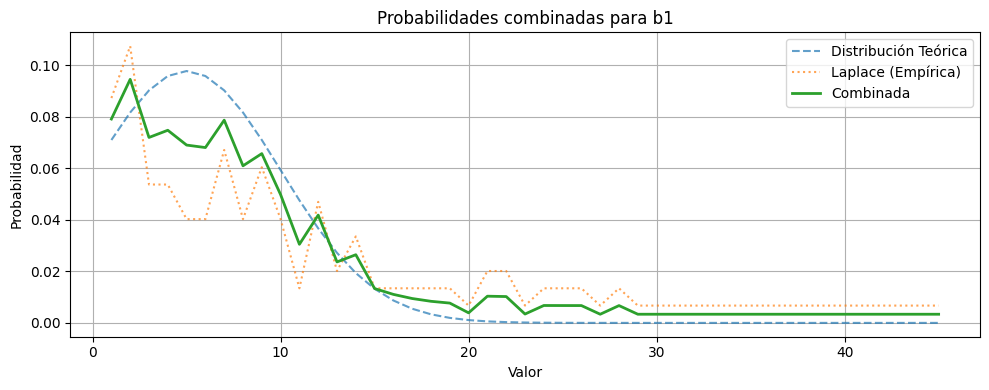

🎯 Siguientes valores más probables para b1:
  2: 0.0945
  1: 0.0791
  7: 0.0787
  4: 0.0747
  3: 0.0720
  5: 0.0690
  6: 0.0680
  9: 0.0657
  8: 0.0610
  10: 0.0498


In [112]:
b1_vals = next_gen_analyze("b1", body_size=104)

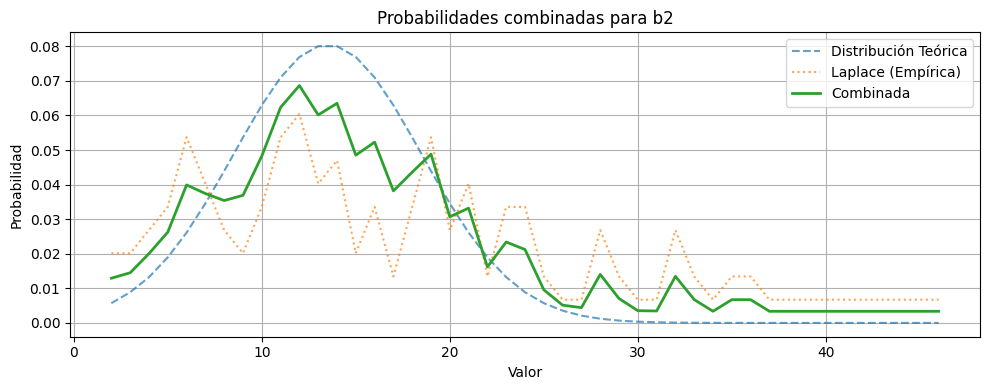

🎯 Siguientes valores más probables para b2:
  12: 0.0687
  14: 0.0635
  11: 0.0623
  13: 0.0602
  16: 0.0523
  19: 0.0488
  15: 0.0485
  10: 0.0483
  18: 0.0436
  6: 0.0399


In [113]:
b2_vals = next_gen_analyze("b2", body_size=104)

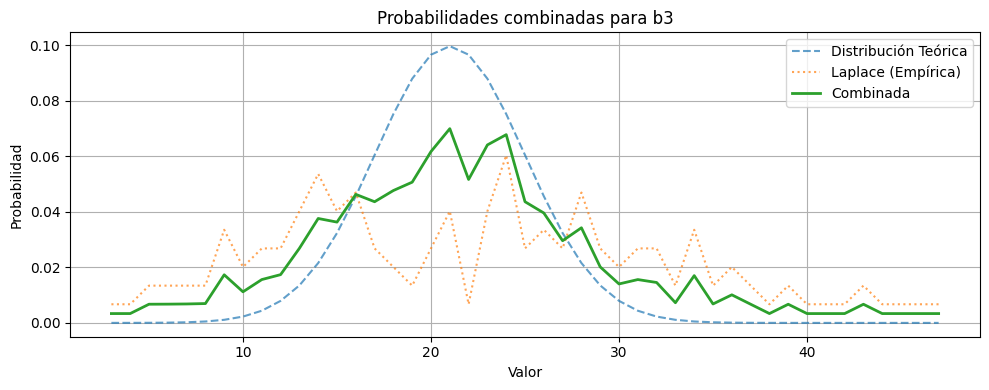

🎯 Siguientes valores más probables para b3:
  21: 0.0700
  24: 0.0678
  23: 0.0641
  20: 0.0618
  22: 0.0517
  19: 0.0507
  18: 0.0477
  16: 0.0463
  17: 0.0437
  25: 0.0437


In [114]:
b3_vals = next_gen_analyze("b3", body_size=104)

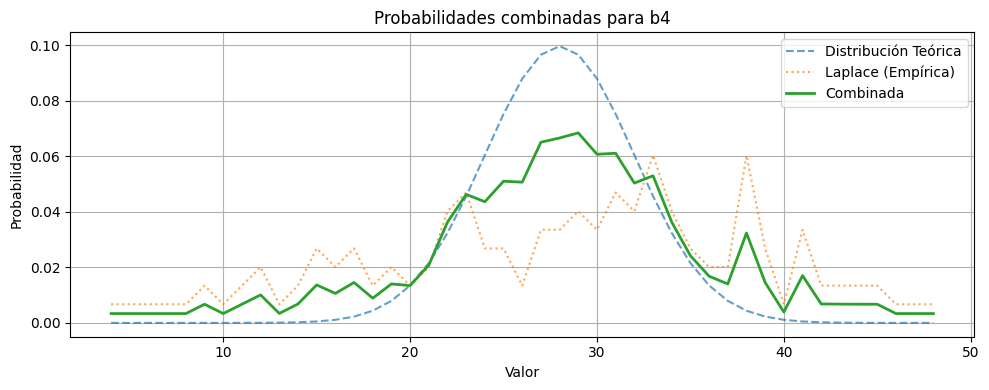

🎯 Siguientes valores más probables para b4:
  29: 0.0685
  28: 0.0666
  27: 0.0651
  31: 0.0611
  30: 0.0608
  33: 0.0530
  25: 0.0511
  26: 0.0507
  32: 0.0504
  23: 0.0463


In [115]:
b4_vals = next_gen_analyze("b4", body_size=104)

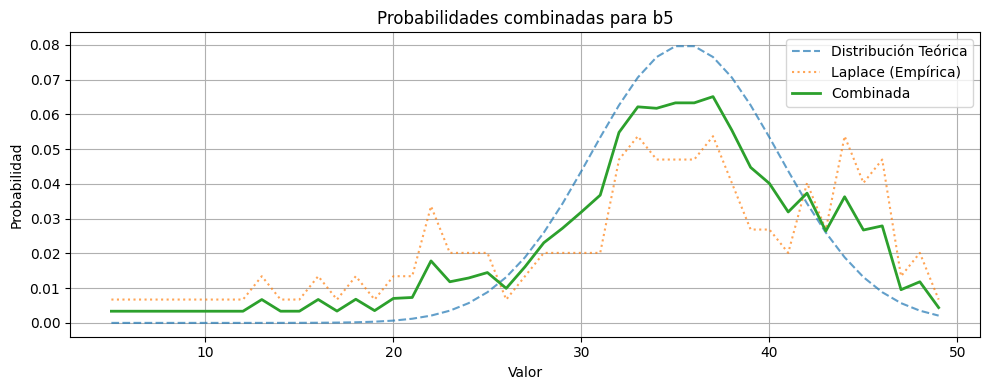

🎯 Siguientes valores más probables para b5:
  37: 0.0651
  35: 0.0633
  36: 0.0633
  33: 0.0621
  34: 0.0617
  38: 0.0554
  32: 0.0548
  39: 0.0447
  40: 0.0401
  42: 0.0373


In [116]:
b5_vals = next_gen_analyze("b5", body_size=104)

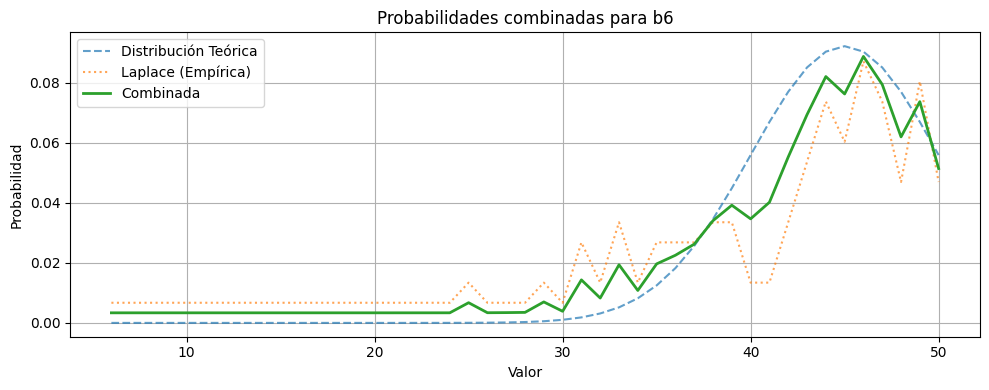

🎯 Siguientes valores más probables para b6:
  46: 0.0888
  44: 0.0821
  47: 0.0795
  45: 0.0763
  49: 0.0738
  43: 0.0694
  48: 0.0620
  42: 0.0553
  50: 0.0515
  41: 0.0402


In [117]:
b6_vals = next_gen_analyze("b6", body_size=104)